# Dataset Preprocessing

In [1]:
# Install libraries if needed
# !pip install torch torchvision opencv-python matplotlib

## 1. Imports

In [2]:
import os
import glob
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch: 2.12.0
GPU available: False


## 2. Dataset Path

In [3]:
# Change this to where you extracted the dataset
# DATA_ROOT = r"C:\Users\tsega\Documents\AI with ML\Image Processing & Comp Vision\Final Project\CityPersons\Citypersons"
DATA_ROOT = "Citypersons"
# Quick check to make sure the folders exist
for split in ['train', 'val']:
    img_path   = os.path.join(DATA_ROOT, 'images', split)
    label_path = os.path.join(DATA_ROOT, 'labels', split)
    print(f"{split} images: {'OK' if os.path.exists(img_path) else 'NOT FOUND'}")
    print(f"{split} labels: {'OK' if os.path.exists(label_path) else 'NOT FOUND'}")

train images: OK
train labels: OK
val images: OK
val labels: OK


## 3. Explore the Dataset

In [4]:
# Count how many images we have
train_images = glob.glob(os.path.join(DATA_ROOT, 'images', 'train', '**', '*.png'), recursive=True)
val_images   = glob.glob(os.path.join(DATA_ROOT, 'images', 'val',   '**', '*.png'), recursive=True)

print(f"Training images:   {len(train_images)}")
print(f"Validation images: {len(val_images)}")

# List the cities in the training set
train_label_dir = os.path.join(DATA_ROOT, 'labels', 'train')
cities = [d for d in os.listdir(train_label_dir) if os.path.isdir(os.path.join(train_label_dir, d))]
print(f"\nCities in training set: {cities}")

Training images:   2975
Validation images: 502

Cities in training set: ['zurich', 'strasbourg', 'weimar', 'aachen', 'tubingen', 'jena', 'bochum', 'darmstadt', 'dusseldorf', 'hamburg', 'cologne', 'monchengladbach', 'krefeld', 'ulm', 'hanover', 'stuttgart', 'erfurt', 'bremen']


In [5]:
# Look at one label file to understand the format
sample_label = glob.glob(os.path.join(DATA_ROOT, 'labels', 'train', '**', '*.txt'), recursive=True)[0]

print(f"Label file: {os.path.basename(sample_label)}\n")
with open(sample_label, 'r') as f:
    lines = f.readlines()

print("Format: class  x_center  y_center  width  height  (all normalized 0-1)")
print("-" * 60)
for line in lines[:5]:
    print(line.strip())
print(f"\nTotal pedestrians in this image: {len(lines)}")

Label file: zurich_000118_000019_leftImg8bit.txt

Format: class  x_center  y_center  width  height  (all normalized 0-1)
------------------------------------------------------------
0 0.640380859375 0.400390625 0.01025390625 0.05078125
0 0.658203125 0.39990234375 0.0087890625 0.0439453125
0 0.5322265625 0.40234375 0.0048828125 0.0234375

Total pedestrians in this image: 3


## 4. Convert YOLO Format to Faster R-CNN Format

YOLO stores boxes as: `x_center, y_center, width, height` (normalized 0-1)  
Faster R-CNN needs: `x_min, y_min, x_max, y_max` (in pixels)

```
x_min = (x_center - width/2)  * image_width
x_max = (x_center + width/2)  * image_width
y_min = (y_center - height/2) * image_height
y_max = (y_center + height/2) * image_height
```

In [6]:
def yolo_to_xyxy(x_c, y_c, w, h, img_w, img_h):
    x_min = (x_c - w / 2) * img_w
    y_min = (y_c - h / 2) * img_h
    x_max = (x_c + w / 2) * img_w
    y_max = (y_c + h / 2) * img_h
    return [x_min, y_min, x_max, y_max]


def read_labels(label_path, img_w, img_h):
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            class_id = int(parts[0])
            if class_id == 0:  # 0 = pedestrian
                box = yolo_to_xyxy(float(parts[1]), float(parts[2]),
                                   float(parts[3]), float(parts[4]),
                                   img_w, img_h)
                boxes.append(box)
    return boxes


print("Conversion functions ready.")

Conversion functions ready.


## 5. Dataset Class

In [7]:
class CityPersonsDataset(Dataset):

    def __init__(self, data_root, split):
        self.split     = split
        self.img_dir   = os.path.join(data_root, 'images', split)
        self.label_dir = os.path.join(data_root, 'labels', split)
        self.images    = sorted(glob.glob(os.path.join(self.img_dir, '**', '*.png'), recursive=True))
        print(f"[{split}] {len(self.images)} images found")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]

        # Derive label path from image path
        label_path = img_path.replace(
            os.path.join('images', self.split),
            os.path.join('labels', self.split)
        ).replace('.png', '.txt')

        # Read image and convert BGR -> RGB
        img    = cv2.imread(img_path)
        img    = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_h, img_w = img.shape[:2]

        # Read bounding boxes
        boxes = read_labels(label_path, img_w, img_h)

        if len(boxes) > 0:
            boxes  = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.ones(len(boxes), dtype=torch.int64)  # 1 = pedestrian
        else:
            boxes  = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros(0, dtype=torch.int64)

        target = {
            "boxes":    boxes,
            "labels":   labels,
            "image_id": torch.tensor([idx]),
            "area":     (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]) if len(boxes) > 0 else torch.zeros(0),
            "iscrowd":  torch.zeros(len(boxes), dtype=torch.int64)
        }

        # Convert image to tensor (also normalizes pixels from [0,255] to [0.0,1.0])
        img_tensor = F.to_tensor(img)

        return img_tensor, target

## 6. Create Datasets and DataLoaders

In [8]:
train_dataset = CityPersonsDataset(DATA_ROOT, split='train')
val_dataset   = CityPersonsDataset(DATA_ROOT, split='val')

[train] 2975 images found
[val] 502 images found


In [9]:
# collate_fn is needed because images can have different numbers of boxes
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=2, shuffle=False, collate_fn=collate_fn)

print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches:   1488
Validation batches: 251


## 7. Quick Check — Look at One Sample

In [10]:
img_tensor, target = train_dataset[0]

print("Image shape:", img_tensor.shape)   # [3, H, W]
print("Pixel range: [{:.2f}, {:.2f}]".format(img_tensor.min().item(), img_tensor.max().item()))
print("Num pedestrians:", len(target['boxes']))
print("First box (pixels):", target['boxes'][0].tolist())

Image shape: torch.Size([3, 1024, 2048])
Pixel range: [0.00, 1.00]
Num pedestrians: 3
First box (pixels): [892.0, 445.0, 913.0, 498.0]


## 8. Visualize Bounding Boxes

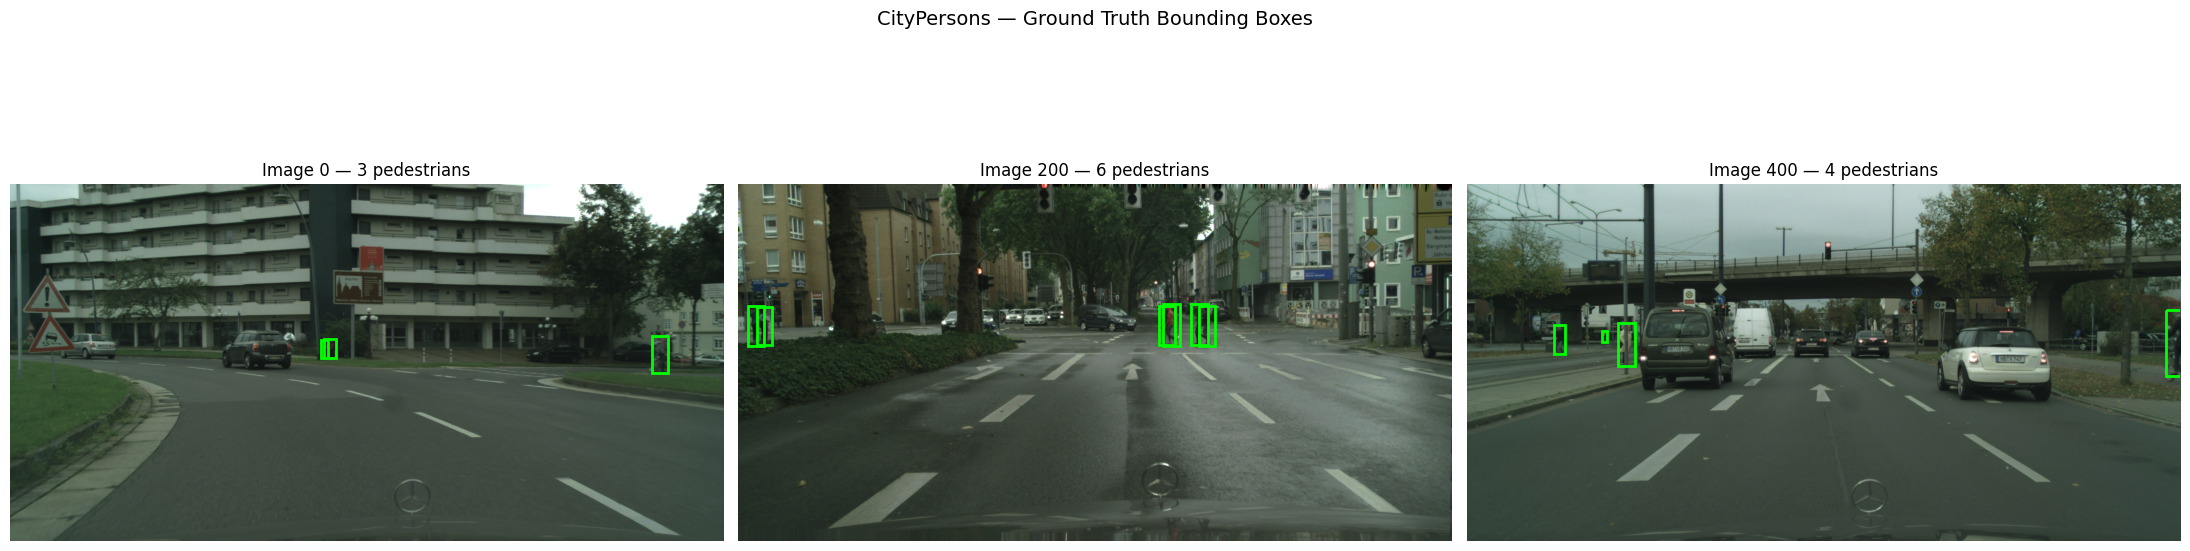

In [11]:
# Show 3 images with their ground truth bounding boxes
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for i, ax in enumerate(axes):
    idx = i * 200
    img_tensor, target = train_dataset[idx]

    # Convert tensor back to numpy for display
    img_np = (img_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    ax.imshow(img_np)

    # Draw each bounding box
    for box in target['boxes'].numpy():
        x_min, y_min, x_max, y_max = box
        rect = patches.Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)

    ax.set_title(f"Image {idx} — {len(target['boxes'])} pedestrians")
    ax.axis('off')

plt.suptitle("CityPersons — Ground Truth Bounding Boxes", fontsize=14)
plt.tight_layout()
plt.show()

Total images:           2975
Total pedestrian boxes: 21002
Avg per image:          7.06
Max in one image:       98


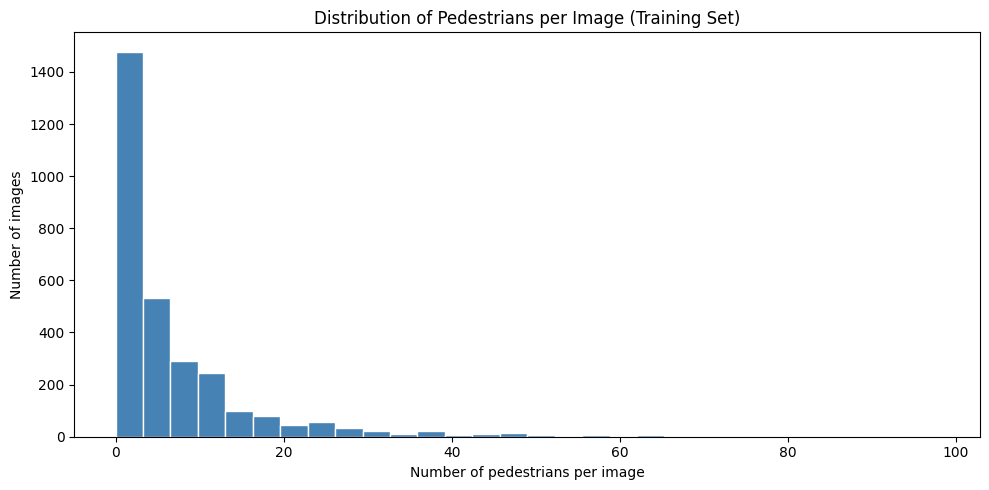

In [12]:
# Count pedestrians per image in the training set
pedestrians_per_image = []

for img_path in train_dataset.images:  # 'images' em vez de 'img_paths'
    label_path = img_path.replace(
        os.path.join('images', 'train'),
        os.path.join('labels', 'train')
    ).replace('.png', '.txt')

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            count = sum(1 for line in f if line.strip().startswith('0'))
    else:
        count = 0
    pedestrians_per_image.append(count)

print(f"Total images:           {len(pedestrians_per_image)}")
print(f"Total pedestrian boxes: {sum(pedestrians_per_image)}")
print(f"Avg per image:          {sum(pedestrians_per_image)/len(pedestrians_per_image):.2f}")
print(f"Max in one image:       {max(pedestrians_per_image)}")

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.hist(pedestrians_per_image, bins=30, color='steelblue', edgecolor='white')
plt.xlabel("Number of pedestrians per image")
plt.ylabel("Number of images")
plt.title("Distribution of Pedestrians per Image (Training Set)")
plt.tight_layout()
plt.show()
